# SWAN procedural example

In this notebook we will use the SWAN Components and data objects to define a SWAN workspace

In [1]:
%load_ext autoreload
%autoreload 2

import shutil
from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from cartopy import crs as ccrs

import warnings

warnings.filterwarnings("ignore")


def display(obj):
    return obj


def check_data(path: Path):
    with xr.open_dataset(path) as ds:
        display(ds)


def plot_nc(
    ncfile,
    varname,
    timestep=None,
    cmap=None,
    grid=None,
):
    """Helper function to plot a variable from a NetCDF file."""
    # display(ncfile)
    if isinstance(ncfile, Path):
        ds = xr.open_dataset(ncfile)
    elif isinstance(ncfile, str):
        ds = xr.open_dataset(Path(ncfile))
    elif isinstance(ncfile, xr.Dataset):
        ds = ncfile
    else:
        raise ValueError("ncfile must be a Path, str, or xarray.Dataset")
    fig = plt.figure(figsize=(10, 5))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ds = xr.open_dataset(ncfile)
    if timestep is not None:
        p = ds[varname].isel(time=timestep).plot(ax=ax, cmap=cmap)
    else:
        p = ds[varname].plot(ax=ax, cmap=cmap)
    ax.coastlines()
    if grid is not None:
        grid.plot(ax=ax)
    plt.title(f"{varname} from {ncfile.name}")
    return p


def plot_spectra(spectra, grid=None, markersize=6, ax=None):
    """Helper function to plot wave spectra from a NetCDF file."""
    if isinstance(spectra, xr.Dataset):
        ds = spectra
    else:
        ds = xr.open_dataset(spectra)

    # display(ds)
    if ax is None:
        fig, ax = plt.subplots(
            figsize=(10, 5), subplot_kw={"projection": ccrs.PlateCarree()}
        )
    else:
        plt.gcf().sca(ax)
    if grid:
        grid.plot(ax=ax)
    c = ds.isel(time=[0]).spec.hs()
    p = ax.scatter(
        ds.lon,
        ds.lat,
        s=markersize,
        c=c,
        cmap="turbo",
        vmin=0,
        vmax=4,
        transform=ccrs.PlateCarree(),
    )
    ax.set_title(c.time.to_index().to_pydatetime()[0])
    plt.colorbar(p, label=f"Hs (m)")
    ax.coastlines()
    ax.grid(True)
    return ax

## Workspace basepath

In [2]:
workdir = Path("example_procedural")
shutil.rmtree(workdir, ignore_errors=True)
workdir.mkdir()

## Model Grid

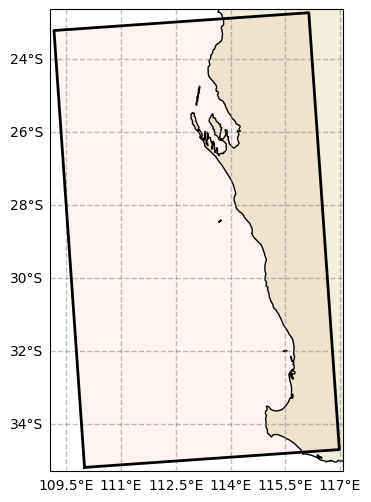

In [3]:
from rompy_swan.grid import SwanGrid

grid = SwanGrid(
    x0=110.0,
    y0=-35.2,
    rot=4.0,
    dx=0.5,
    dy=0.5,
    nx=15,
    ny=25,
)

fig, ax = grid.plot(fscale=6)

## Work with existing data

We will work with subsets of global bathymetry from Gebco, winds from ERA5 and spectral boundary from Oceanum available in Rompy. Some dummy interpolation routine is used to exemplify how existing xarray datasources could be processed and then provided to rompy to define the model config

In [4]:
from rompy.core.time import TimeRange
from rompy.core.types import DatasetCoords
from rompy_swan.data import SwanDataGrid
from rompy.core.source import SourceFile
from rompy_swan.boundary import Boundnest1

projection = ccrs.PlateCarree()

In [5]:
def my_fancy_interpolation(
    dset: xr.Dataset,
    grid: SwanGrid,
    coords: DatasetCoords,
    buffer: float = 0.0,
) -> xr.Dataset:
    """Dummy interpolation function."""
    x0, y0, x1, y1 = grid.bbox(buffer)
    xarr = np.arange(x0, x1 + grid.dx, grid.dx)
    yarr = np.arange(y0, y1 + grid.dy, grid.dy)
    return dset.interp(**{coords.x: xarr, coords.y: yarr})

In [6]:
DATADIR = Path("../tests/data")
display(sorted(DATADIR.glob("*")))

gebco_file = DATADIR / "gebco-1deg.nc"
era5_file = DATADIR / "era5-20230101.nc"
spectra_file = DATADIR / "aus-20230101.nc"

### Times

In [7]:
# Define a time object to run the model using the time range from ERA5 dataset

with xr.open_dataset(era5_file) as era5:
    start, end = era5.time.to_index()[[0, -1]]
    times = TimeRange(start=start, end=end, interval="1h")
    print(times)


	Start: 2023-01-01 00:00:00
	End: 2023-01-02 00:00:00
	Duration: 1 day
	Interval: 1:00:00
	Include End: True



### Bathy

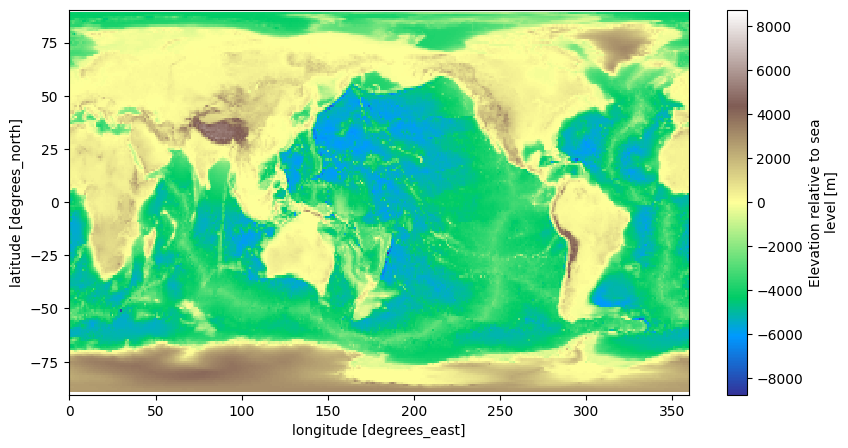

In [8]:
# Display the GEBCO dataset

gebco = xr.open_dataset(gebco_file)
display(gebco)
p = gebco.elevation.plot(figsize=(10, 5), cmap="terrain")

In [9]:
# Process gebco into the model bathy

dset = my_fancy_interpolation(gebco, grid, DatasetCoords(x="lon", y="lat"), buffer=1.0)
dset

<xarray.Dataset> Size: 5kB
Dimensions:    (lat: 30, lon: 21)
Coordinates:
  * lat        (lat) float64 240B -36.2 -35.7 -35.2 -34.7 ... -22.7 -22.2 -21.7
  * lon        (lon) float64 168B 108.2 108.7 109.2 109.7 ... 117.2 117.7 118.2
Data variables:
    elevation  (lat, lon) float64 5kB -5.443e+03 -5.552e+03 ... 333.9 346.7
Attributes:
    title:    Subset of the GEBCO 2020 grid for testing purposes

(<Figure size 500x600 with 2 Axes>,
 <GeoAxes: xlabel='longitude [degrees_east]', ylabel='latitude [degrees_north]'>)

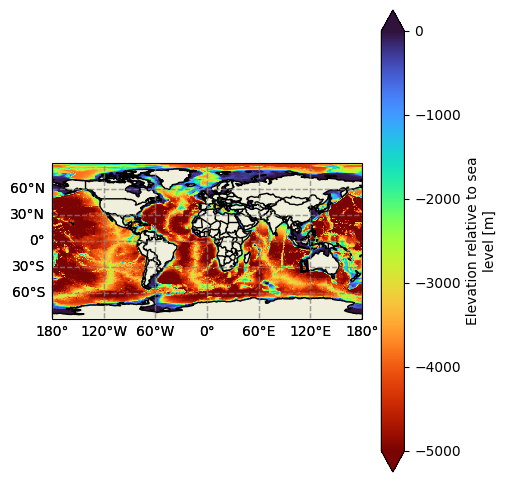

In [10]:
# Create and plot the data instance. This object will be provided to the SWAN Config through the DataInterface

bottom = SwanDataGrid(
    var="bottom",
    source=SourceFile(uri=gebco_file),
    z1="elevation",
    fac=-1,
    coords={"x": "lon", "y": "lat"},
    crop_data=False,  # So data isn't cropped to model grid inside SwanConfig
)

fig, ax = bottom.plot(
    param="elevation", vmin=-5000, vmax=0, cmap="turbo_r", figsize=(5, 6)
)
grid.plot(ax=ax)

### Winds

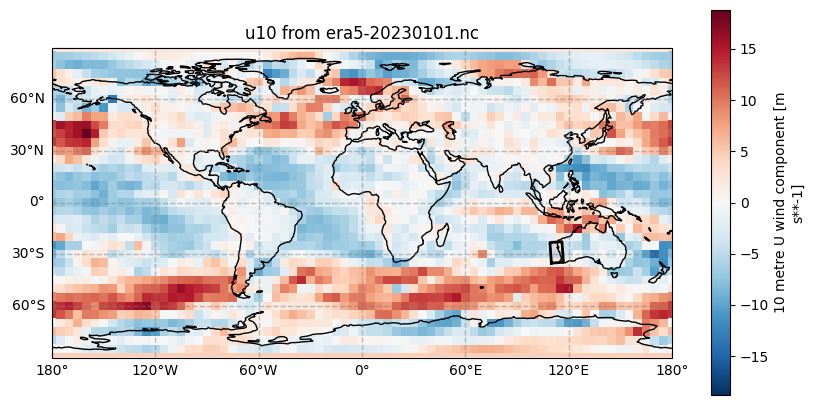

In [11]:
# Display the ERA dataset

check_data(era5_file)

plot_nc(era5_file, "u10", timestep=0, cmap="RdBu_r", grid=grid)

In [12]:
# Process it into the model forcing

dset = my_fancy_interpolation(
    era5, grid, DatasetCoords(x="longitude", y="latitude"), buffer=1.0
)
dset

<xarray.Dataset> Size: 51kB
Dimensions:    (time: 5, latitude: 30, longitude: 21)
Coordinates:
  * time       (time) datetime64[ns] 40B 2023-01-01 ... 2023-01-02
  * latitude   (latitude) float64 240B -36.2 -35.7 -35.2 ... -22.7 -22.2 -21.7
  * longitude  (longitude) float64 168B 108.2 108.7 109.2 ... 117.2 117.7 118.2
Data variables:
    u10        (time, latitude, longitude) float64 25kB 3.054 3.084 ... 1.339
    v10        (time, latitude, longitude) float64 25kB 4.884 4.951 ... 0.9003
Attributes:
    Conventions:  CF-1.6
    history:      2023-06-10 00:03:38 GMT by grib_to_netcdf-2.25.1: /opt/ecmw...

In [13]:
# ERA5 has Latitude in reverse order, use filter to reverse it

from rompy.core.filters import Filter

(<Figure size 500x600 with 2 Axes>,
 <GeoAxes: title={'center': 'time = 2023-01-01'}, xlabel='longitude', ylabel='latitude'>)

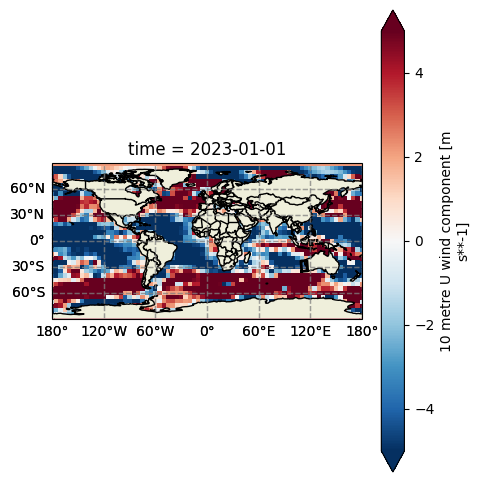

In [50]:
# Create and plot the data instance. This object will be provided to the SWAN Config through the DataInterface

wind = SwanDataGrid(
    var="wind",
    source=SourceFile(uri=era5_file),
    z1="u10",
    z2="v10",
    coords={"x": "longitude", "y": "latitude"},
    crop_data=True,  # So data isn't cropped to model grid inside SwanConfig
    filter=Filter(sort=dict(coords=["latitude"])),
)

fig, ax = wind.plot(
    param="u10", isel={"time": 0}, vmin=-5, vmax=5, cmap="RdBu_r", figsize=(5, 6)
)
grid.plot(ax=ax)

### Boundary

<GeoAxes: title={'center': '2023-01-01 00:00:00'}>

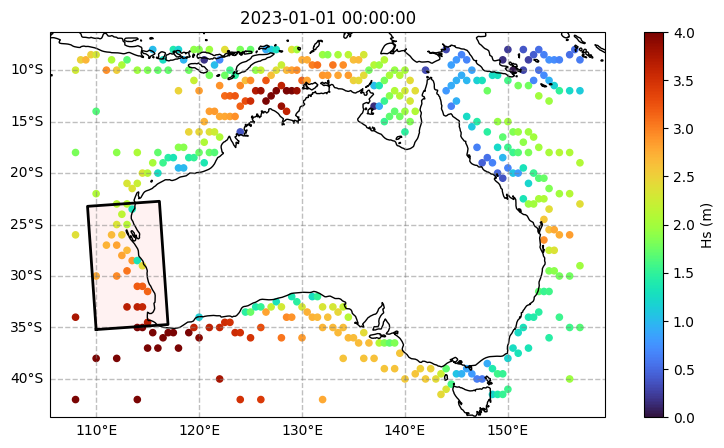

In [15]:
# Open and check the test spectra dataset

check_data(spectra_file)
plot_spectra(spectra_file, grid=grid, markersize=20)

In [16]:
# Create the boundary instance. This object will be provided to the SWAN Config through the BoundaryInterface

boundary_from_data = Boundnest1(
    id="westaus",
    source=SourceFile(uri=spectra_file),
    sel_method="idw",
    sel_method_kwargs={
        "tolerance": 4
    },  # points are sparse around the offshore boundary so make sure tolerance is appropriate
)

<GeoAxes: title={'center': '2023-01-01 00:00:00'}>

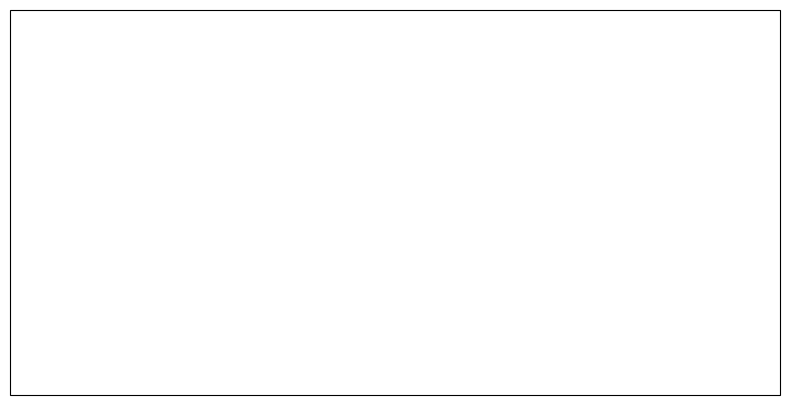

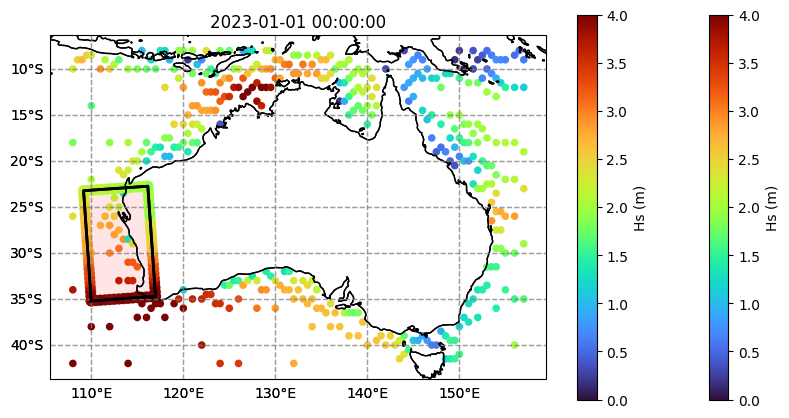

In [17]:
# Generate the boundary data and plot them to check.
# This isn't necessary but it is useful for checking the generated boundary look okay

# Generate the boundary data
outfile, cmd = boundary_from_data.get(destdir=workdir, grid=grid, time=times)

# Read the boundary data into an xarray dataset
from wavespectra import read_swan

ds = read_swan(outfile)
display(ds)

# Plot the boundary data alongside the source dataset and the model grid
fig, ax = plt.subplots(figsize=(10, 5), subplot_kw={"projection": projection})


# # Source dataset
# c = oceanum.isel(time=[0]).spec.hs()
# p = ax.scatter(
#     oceanum.lon, oceanum.lat, s=20, c=c, marker="v", cmap="turbo", vmin=0, vmax=4
# )

ax = plot_spectra(spectra_file, grid=grid, markersize=20)
plot_spectra(ds, grid=grid, markersize=50, ax=ax)

# # Generated boundary dataset
# c = ds.isel(time=[0]).spec.hs()
# p = ax.scatter(
#     ds.lon, ds.lat, s=50, c=c, cmap="turbo", edgecolors="0.5", vmin=0, vmax=4
# )
#
# # Model grid
# grid.plot(ax=ax)

# # Axis settings
# ax.set_title(c.time.to_index().to_pydatetime()[0])
# plt.colorbar(p, label=f"Hs (m)")
# ax.coastlines()
# ax.set_extent([ds.lon.min() - 3, ds.lon.max() + 3, ds.lat.min() - 3, ds.lat.max() + 3])
#

## SWAN components

SWAN commands can be fully prescribed using what we define as "Components". Components
are pydantic objects that describe the different sets of command instruction in SWAN
with fields that matching command options and a `render()` method that returns the
string to render in the `INPUT` command file.

The `SwanConfig` config class takes the components as fields organised as
"group" components, a collection of individual components that are defined together and
validated for consistency. These groups are structured similarly to the main groups of
SWAN commands as defined by the subsections in
[Chapter 4](https://swanmodel.sourceforge.io/online_doc/swanuse/node20.html) of the user manual.

In [18]:
from rompy_swan.config import SwanConfig

SwanConfig?

Init signature:
SwanConfig(
    *,
    model_type: Literal['swan', 'SWAN'] = 'swan',
    template: str = '/home/tdurrant/source/rompy/perth_demo/.venv/lib64/python3.13/site-packages/rompy_swan/templates/swan',
    checkout: Optional[str] = 'main',
    cgrid: Union[rompy_swan.components.cgrid.REGULAR, rompy_swan.components.cgrid.CURVILINEAR, rompy_swan.components.cgrid.UNSTRUCTURED],
    startup: Optional[Annotated[rompy_swan.components.group.STARTUP, FieldInfo(annotation=NoneType, required=True, description='Startup components')]] = None,
    inpgrid: Optional[Annotated[Union[rompy_swan.components.group.INPGRIDS, rompy_swan.interface.DataInterface], FieldInfo(annotation=NoneType, required=True, description='Input grid components', discriminator='model_type')]] = None,
    boundary: Optional[Annotated[Union[rompy_swan.components.boundary.BOUNDSPEC, rompy_swan.components.boundary.BOUNDNEST1, rompy_swan.components.boundary.BOUNDNEST2, rompy_swan.components.boundary.BOUNDNEST3, rompy_swan.

### CGRID

In [19]:
from rompy_swan.components.cgrid import REGULAR
from rompy_swan.subcomponents.readgrid import GRIDREGULAR
from rompy_swan.subcomponents.spectrum import SPECTRUM

cgrid = REGULAR(
    grid=GRIDREGULAR(
        xp=grid.x0,
        yp=grid.y0,
        alp=grid.rot,
        xlen=grid.xlen,
        ylen=grid.ylen,
        mx=grid.nx - 1,
        my=grid.ny - 1,
    ),
    spectrum=SPECTRUM(
        mdc=36,
        flow=0.04,
        fhigh=1.0,
    ),
)

print(cgrid.render())

CGRID REGULAR xpc=110.0 ypc=-35.2 alpc=4.0 xlenc=7.0 ylenc=12.0 mxc=14 myc=24 CIRCLE mdc=36 flow=0.04 fhigh=1.0


### Startup

In [20]:
from rompy_swan.components.group import STARTUP
from rompy_swan.components.startup import PROJECT, SET, MODE, COORDINATES
from rompy_swan.subcomponents.startup import SPHERICAL

project = PROJECT(
    name="Test procedural",
    nr="run1",
    title1="Procedural definition of a Swan config with rompy",
)

set = SET(level=0.0, depmin=0.05, direction_convention="nautical")

mode = MODE(kind="nonstationary", dim="twodimensional")

coordinates = COORDINATES(kind=SPHERICAL())

startup = STARTUP(
    project=project,
    set=set,
    mode=mode,
    coordinates=coordinates,
)

print(startup.render())

PROJECT name='Test procedural' nr='run1' title1='Procedural definition of a Swan config with rompy'

SET level=0.0 depmin=0.05 NAUTICAL

MODE NONSTATIONARY TWODIMENSIONAL

COORDINATES SPHERICAL CCM


### Input grids

We will prescribe input grids from our previously defined `SwanDataGrid` objects using
the `DataInterface` object. This object is used by `SwanConfig` as an
interface to pass around times and grids between model and data objects, create model
input times and generate consistent CMD instructions.

In [21]:
from rompy_swan.interface import DataInterface

inpgrid = DataInterface(
    bottom=bottom,
    input=[wind],
)

inpgrid

DataInterface(model_type='data_interface', bottom=SwanDataGrid(model_type='grid', id='data', source=SourceFile(model_type='file', uri=PosixPath('../tests/data/gebco-1deg.nc'), kwargs={}, variable=None), filter=Filter(sort={}, subset={}, crop={}, timenorm={}, rename={}, derived={}), variables=['elevation'], coords=DatasetCoords(t='time', x='lon', y='lat', z=None, s=None), crop_data=False, buffer=0.0, time_buffer=[0, 0], z1='elevation', z2=None, var=<GridOptions.BOTTOM: 'bottom'>, fac=-1.0), input=[SwanDataGrid(model_type='grid', id='data', source=SourceFile(model_type='file', uri=PosixPath('../tests/data/era5-20230101.nc'), kwargs={}, variable=None), filter=Filter(sort={'coords': ['latitude']}, subset={}, crop={}, timenorm={}, rename={}, derived={}), variables=['u10', 'v10'], coords=DatasetCoords(t='time', x='longitude', y='latitude', z=None, s=None), crop_data=False, buffer=0.0, time_buffer=[0, 0], z1='u10', z2='v10', var=<GridOptions.WIND: 'wind'>, fac=1.0)])

### Boundary

Boundary can be defined either from a SWAN boundary component or using the `BoundaryInterface` class which works in an analogous way to `DataInterface`.

Below we define a pure parametric boundary using the `BOUNDSPEC` component just to demonstrate it:

In [22]:
from rompy_swan.components.boundary import BOUNDSPEC
from rompy_swan.subcomponents.boundary import SIDE, CONSTANTPAR
from rompy_swan.subcomponents.spectrum import SHAPESPEC, JONSWAP

shape = JONSWAP(gamma=3.3)

shapespec = SHAPESPEC(shape=shape, per_type="peak", dspr_type="degrees")

location = SIDE(side="west", direction="ccw")

data = CONSTANTPAR(hs=2.0, per=12.0, dir=255.0, dd=25.0)

boundary_parametric = BOUNDSPEC(shapespec=shapespec, location=location, data=data)

print(boundary_parametric.render())

BOUND SHAPESPEC JONSWAP gamma=3.3 PEAK DSPR DEGREES
BOUNDSPEC SIDE WEST CCW CONSTANT PAR hs=2.0 per=12.0 dir=255.0 dd=25.0


And here we define boundary from the data using the `BoundaryInterface` object which interfaces that with the time and grid objects within `SwanConfig`:

In [23]:
from rompy_swan.interface import BoundaryInterface

boundary_interface = BoundaryInterface(kind=boundary_from_data)

boundary_interface

BoundaryInterface(model_type='boundary_interface', kind=Boundnest1(model_type='boundnest1', id='westaus', source=SourceFile(model_type='file', uri=PosixPath('../tests/data/aus-20230101.nc'), kwargs={}, variable=None), filter=Filter(sort={}, subset={}, crop={'time': Slice(start=Timestamp('2023-01-01 00:00:00'), stop=Timestamp('2023-01-02 00:00:00')), 'longitude': Slice(start=107.1629223150705, stop=118.98294835181876), 'latitude': Slice(start=-37.2, stop=-20.740936080673237)}, timenorm={}, rename={}, derived={}), variables=['efth', 'lon', 'lat'], coords=DatasetCoords(t='time', x='longitude', y='latitude', z=None, s=None), crop_data=True, buffer=2.0, time_buffer=[0, 0], spacing=None, sel_method='idw', sel_method_kwargs={'tolerance': 4}, grid_type='boundary_wave_station', rectangle='closed'))

### Initial conditions

Components are available to represent the different initial conditions options in SWAN
including `DEFAULT`, `ZERO`, `PAR` and `HOTSTART`

TODO: define an interface to define initial conditions.

In [24]:
from rompy_swan.components.boundary import INITIAL
from rompy_swan.subcomponents.boundary import DEFAULT

initial = INITIAL(kind=DEFAULT())

print(initial.render())

INITIAL DEFAULT


### Physics

The Components support every SWAN physics command option. They are prescribed in the
`SwanConfig` using the PHYSICS group component.

In [25]:
from rompy_swan.components.group import PHYSICS
from rompy_swan.components.physics import (
    GEN3,
    BREAKING_CONSTANT,
    FRICTION_RIPPLES,
    QUADRUPL,
    TRIAD,
)
from rompy_swan.subcomponents.physics import WESTHUYSEN

gen = GEN3(source_terms=WESTHUYSEN(wind_drag="wu", cds2=5.0e-5, br=1.75e-3))

breaking = BREAKING_CONSTANT(alpha=1.0, gamma=0.73)

friction = FRICTION_RIPPLES(s=2.65, d=0.0001)

triad = TRIAD(itriad=1)

quad = QUADRUPL(iquad=2, lambd=0.25, cnl4=3.0e7, csh1=5.5, csh2=0.833, csh3=-1.25)

physics = PHYSICS(
    gen=gen,
    breaking=breaking,
    friction=friction,
    triad=triad,
    quadrupl=quad,
)

print(physics.render())

GEN3 WESTHUYSEN cds2=5e-05 br=0.00175 DRAG WU

QUADRUPL iquad=2 lambda=0.25 cnl4=30000000.0 csh1=5.5 csh2=0.833 csh3=-1.25

BREAKING CONSTANT alpha=1.0 gamma=0.73

FRICTION RIPPLES S=2.65 D=0.0001

TRIAD itriad=1


### Propagation scheme

In [26]:
from rompy_swan.components.numerics import PROP
from rompy_swan.subcomponents.numerics import BSBT

prop = PROP(scheme=BSBT())

print(prop.render())

PROP BSBT


### Numerics

In [27]:
from rompy_swan.components.numerics import NUMERIC
from rompy_swan.subcomponents.numerics import STAT, STOPC, DIRIMPL

stopc = STOPC(dabs=0.02, drel=0.02, curvat=0.02, npnts=98, mode=STAT(mxitst=50))

dirimpl = DIRIMPL(cdd=0.5)

numeric = NUMERIC(stop=stopc, dirimpl=dirimpl)

print(numeric.render())

NUMERIC STOPC dabs=0.02 drel=0.02 curvat=0.02 npnts=98.0 STATIONARY mxitst=50 DIRIMPL cdd=0.5


### Output

Output commands are defined in `SwanConfig` with the `OUTPUT` group component.
Many validations are defined to ensure location and write components are prescribed correctly.

The output write components (and the lockup ones) require times, however we can skip
defining times here as `SwanConfig` will ensure consistent times are
defined for all time-dependant components.

In [28]:
from rompy_swan.components.group import OUTPUT
from rompy_swan.components.output import (
    POINTS,
    QUANTITY,
    QUANTITIES,
    BLOCK,
    TABLE,
    SPECOUT,
)
from rompy_swan.subcomponents.output import SPEC2D, ABS
from rompy_swan.subcomponents.time import TimeRangeOpen

points = POINTS(
    sname="pts",
    xp=[114.0, 112.5, 115.0],
    yp=[-34.0, -26.0, -30.0],
)

q1 = QUANTITY(output=["hsign"], hexp=50.0)
q2 = QUANTITY(output=["hsign", "tps"], fmin=0.04, fmax=0.3)
q3 = QUANTITY(output=["hswell"], fswell=0.125)
quantity = QUANTITIES(quantities=[q1, q2, q3])

block = BLOCK(
    sname="COMPGRID",
    fname="outgrid.nc",
    output=["depth", "wind", "hsign", "hswell", "dir", "tps"],
    times=TimeRangeOpen(tfmt=1, dfmt="min"),  # Default times which will be overwritten
    idla=3,
)

table = TABLE(
    sname="pts",
    fname="outpts.txt",
    output=["time", "hsign", "dir", "tps", "tm01"],
    times=TimeRangeOpen(tfmt=1, dfmt="min"),  # Default times which will be overwritten
)

specout = SPECOUT(
    sname="pts",
    fname="swanspec.nc",
    dim=SPEC2D(),
    freq=ABS(),
    times=TimeRangeOpen(tfmt=1, dfmt="min"),  # Default times which will be overwritten
)

output = OUTPUT(
    points=points,
    quantity=quantity,
    block=block,
    table=table,
    specout=specout,
)

print(output.render())

POINTS sname='pts' &
    xp=114.0 yp=-34.0 &
    xp=112.5 yp=-26.0 &
    xp=115.0 yp=-30.0

QUANTITY HSIGN hexp=50.0

QUANTITY HSIGN TPS fmin=0.04 fmax=0.3

QUANTITY HSWELL fswell=0.125

BLOCK sname='COMPGRID' fname='outgrid.nc' LAYOUT idla=3 &
    DEPTH &
    WIND &
    HSIGN &
    HSWELL &
    DIR &
    TPS &
    OUTPUT tbegblk=19700101.000000 deltblk=60.0 MIN

TABLE sname='pts' fname='outpts.txt' &
    TIME &
    HSIGN &
    DIR &
    TPS &
    TM01 &
    OUTPUT tbegtbl=19700101.000000 delttbl=60.0 MIN

SPECOUT sname='pts' SPEC2D ABS fname='swanspec.nc' OUTPUT tbegspc=19700101.000000 deltspc=60.0 MIN


### Lockup

The lockup components are prescribed to the `SwanConfig` class from the `LOCKUP`
group component. similar to the output components, time-based fields do not need to be
prescribed as they will be reset in the config class, however some time parameters such as
`tfmt` and `dfmt` are maintained if defined so they could be defined here.

In [29]:
from rompy_swan.components.group import LOCKUP
from rompy_swan.components.lockup import COMPUTE_STAT, HOTFILE
from rompy_swan.subcomponents.time import NONSTATIONARY

hotfile = HOTFILE(fname="hotfile.swn", format="free")

compute = COMPUTE_STAT(
    times=NONSTATIONARY(
        tfmt=1, dfmt="hr"
    ),  # We use nonstationary times here to prescribe multiple STAT commands
    hotfile=hotfile,
    hottimes=[1, -1],  # Output hotfile after the 2nd and last time steps
)

lockup = LOCKUP(compute=compute)

print(lockup.render())

COMPUTE STATIONARY time=19700101.000000
COMPUTE STATIONARY time=19700101.010000
HOTFILE fname='hotfile_19700101T010000.swn' FREE
COMPUTE STATIONARY time=19700101.020000
COMPUTE STATIONARY time=19700101.030000
COMPUTE STATIONARY time=19700101.040000
COMPUTE STATIONARY time=19700101.050000
COMPUTE STATIONARY time=19700101.060000
COMPUTE STATIONARY time=19700101.070000
COMPUTE STATIONARY time=19700101.080000
COMPUTE STATIONARY time=19700101.090000
COMPUTE STATIONARY time=19700101.100000
COMPUTE STATIONARY time=19700101.110000
COMPUTE STATIONARY time=19700101.120000
COMPUTE STATIONARY time=19700101.130000
COMPUTE STATIONARY time=19700101.140000
COMPUTE STATIONARY time=19700101.150000
COMPUTE STATIONARY time=19700101.160000
COMPUTE STATIONARY time=19700101.170000
COMPUTE STATIONARY time=19700101.180000
COMPUTE STATIONARY time=19700101.190000
COMPUTE STATIONARY time=19700101.200000
COMPUTE STATIONARY time=19700101.210000
COMPUTE STATIONARY time=19700101.220000
COMPUTE STATIONARY time=1970010

### Instantiate config

Note each field is optional so it is possible to skip defining a certain group component
such as `prop` to allow using default options in SWAN.

In [30]:
config = SwanConfig(
    cgrid=cgrid,
    startup=startup,
    inpgrid=inpgrid,
    initial=initial,
    boundary=boundary_interface,
    physics=physics,
    prop=prop,
    numeric=numeric,
    output=output,
    lockup=lockup,
)

### Generate workspace

In [31]:
from rompy.model import ModelRun
from rompy.core.time import TimeRange

model_run = ModelRun(
    run_id="run1",
    period=times,
    output_dir=str(workdir),
    config=config,
)

rundir = model_run()

2025-11-14 22:51:15 [INFO] rompy.model         : ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
2025-11-14 22:51:15 [INFO] rompy.model         : ┃                      MODEL RUN CONFIGURATION                       ┃
2025-11-14 22:51:15 [INFO] rompy.model         : ┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛
2025-11-14 22:51:15 [INFO] rompy.model         :             Run ID : run1
2025-11-14 22:51:15 [INFO] rompy.model         :         Model Type : SwanConfig
2025-11-14 22:51:15 [INFO] rompy.model         :         Start Time : 2023-01-01T00:00:00
2025-11-14 22:51:15 [INFO] rompy.model         :           End Time : 2023-01-02T00:00:00
2025-11-14 22:51:15 [INFO] rompy.model         :           Duration : 1 day
2025-11-14 22:51:15 [INFO] rompy.model         :      Time Interval : 1:00:00
2025-11-14 22:51:15 [INFO] rompy.model         :   Output Directory : example_procedural
2025-11-14 22:51:15 [INFO] rompy.model         : ┏━━━━━━━━━━━

### Check the workspace

In [32]:
modeldir = Path(model_run.output_dir) / model_run.run_id

sorted(modeldir.glob("*"))

[PosixPath('example_procedural/run1/INPUT'),
 PosixPath('example_procedural/run1/bottom.grd'),
 PosixPath('example_procedural/run1/westaus.bnd'),
 PosixPath('example_procedural/run1/wind.grd')]

In [33]:
input = modeldir / "INPUT"
print(input.read_text())

! Rompy SwanConfig
! Template: /home/tdurrant/source/rompy/perth_demo/.venv/lib64/python3.13/site-packages/rompy_swan/templates/swan
! Generated: 2025-11-14 11:51:15.402050+00:00 on customer.sngesgp1.pop.starlinkisp.net by tdurrant


! Startup -------------------------------------------------------------------------------------------------------------------------------------------------------------------------

PROJECT name='Test procedural' nr='run1' title1='Procedural definition of a Swan config with rompy'

SET level=0.0 depmin=0.05 NAUTICAL

MODE NONSTATIONARY TWODIMENSIONAL

COORDINATES SPHERICAL CCM

! Computational Grid --------------------------------------------------------------------------------------------------------------------------------------------------------------


CGRID REGULAR xpc=110.0 ypc=-35.2 alpc=4.0 xlenc=7.0 ylenc=12.0 mxc=14 myc=24 CIRCLE mdc=36 flow=0.04 fhigh=1.0

! Input Grids -----------------------------------------------------------------------------

# Model Execution

With the complete configuration ready, we can now execute the SCHISM simulation. The model run process involves:

## Execution Steps:
1. **Workspace preparation**: Generate all input files in the correct format
2. **Model compilation**: Build SWAN executable (if using Docker)
3. **Parallel execution**: Run SWAN using MPI for parallel processing
4. **Output generation**: Write results to NetCDF files

## Performance Considerations:
- **Grid size**: Larger grids require more computational resources
- **Time step**: Smaller time steps increase accuracy but require more computation
- **Output frequency**: More frequent output increases I/O overhead
- **Parallel scaling**: Optimal core count depends on grid size and domain decomposition

Note: Most configuration fields use default values optimized for typical coastal applications.

# SWAN Model Execution

The generated workspace now has all required in puts to perform the swan run. This can be done independent of rompy, using, for example,
exiting swan binaries installed on a users system. HOwever, we will  execute the SWAN model using the rompy backend system.
This system provides flexible execution options including Docker containerization for reproducible, portable simulations.

## Available Execution Backends:

### Run Backends:
- **Local**: Direct execution on the local machine
- **Docker**: Containerized execution for reproducibility
- **HPC**: High-performance computing cluster integration

### Pipeline Backends:
- **Sequential**: Run components in order
- **Parallel**: Execute independent components simultaneously

### Postprocessors:
- **Output conversion**: Transform results to different formats
- **Visualization**: Generate plots and animations
- **Analysis**: Compute derived quantities and statistics

The Docker backend provides several advantages:
- **Reproducible environment**: Consistent SWAN build across systems
- **Dependency isolation**: No conflicts with local software
- **Portable execution**: Run anywhere Docker is available
- **Version control**: Specific SWAN versions with known configurations

See https://rom-py.github.io/rompy/backends.html# for details.

In [34]:
# Discover available execution backends
# This shows all the backend options available in the current rompy installation

from rompy.model import RUN_BACKENDS, POSTPROCESSORS, PIPELINE_BACKENDS

print("Available Run Backends:")
print("=" * 50)
for name, backend_class in RUN_BACKENDS.items():
    print(f"  • {name}: {backend_class.__name__}")

print(f"\nAvailable Postprocessors:")
print("=" * 50)
for name, processor_class in POSTPROCESSORS.items():
    print(f"  • {name}: {processor_class.__name__}")

print(f"\nAvailable Pipeline Backends:")
print("=" * 50)
for name, pipeline_class in PIPELINE_BACKENDS.items():
    print(f"  • {name}: {pipeline_class.__name__}")

print(
    f"\nTotal backends available: {len(RUN_BACKENDS) + len(POSTPROCESSORS) + len(PIPELINE_BACKENDS)}"
)

Available Run Backends:
  • docker: DockerRunBackend
  • local: LocalRunBackend

Available Postprocessors:
  • noop: NoopPostprocessor
  • datamesh: DataMeshPostprocessor

Available Pipeline Backends:
  • local: LocalPipelineBackend
  • prax: PraxPipelineBackend

Total backends available: 6


### Docker Backend Configuration

The Docker backend allows us to run SWAN in a containerized environment using a pre-built Dockerfile. This approach offers several benefits:

#### Advantages of Docker Execution:
- **Consistent environment**: Same SWAN build regardless of host system
- **Reproducible results**: Identical execution environment across different machines
- **No local dependencies**: SWAN and all libraries contained in the image
- **Version control**: Specific SWAN versions with known configurations
- **Resource management**: Control CPU, memory, and other system resources

#### Docker Configuration Parameters:
- **Dockerfile**: Path to SWAN build instructions
- **Build context**: Directory containing source code and dependencies
- **Resources**: CPU cores, memory limits, execution timeout
- **Volumes**: Mount points for input/output data exchange
- **Environment**: Variables for MPI and execution control

No lets run the model using this dockerfile. We can provide an image, or a Dockerfile that will be build. In this case, we are providing a dockerfile, so this should build the docker (which will take a few minutes the first time its run)

In [35]:
# Configure Docker backend for SWAN execution
# This Docker builds multiple SWAN versions - we'll use v5.13.0 with wave coupling

from rompy.backends.config import DockerConfig


# MPI execution command for containerized SWAN
# Running on 8 cores with 4 scribes (output processors)
# command = f"cd /tmp/swan && mpirun --oversubscribe --allow-run-as-root -n 8 swan.exe"
command = f"swan.exe"

# Create Docker configuration object
docker_config = DockerConfig(
    # Docker build configuration
    dockerfile=Path("Dockerfile"),  # Dockerfile for SCHISM build
    build_context=Path("../docker"),  # Build context directory
    # Resource limits and timeouts
    timeout=3600,  # 1 hour execution timeout
    cpu=8,  # Number of CPU cores
    memory="4g",  # Memory limit
    # Execution configuration
    executable=f'bash -c "{command}"',  # Command to run inside container
    # Environment variables for MPI execution
    env_vars={
        "OMPI_ALLOW_RUN_AS_ROOT": "1",  # Allow root user in MPI
        "OMPI_ALLOW_RUN_AS_ROOT_CONFIRM": "1",  # Confirm root user permission
    },
    # Container management
    remove_container=True,  # Clean up after execution
    user="root",  # Run as root user
)

# Execute the model using Docker backend
print("Starting SWAN execution in Docker container...")
print(f"Command: {command}")
print(f"Resources: {docker_config.cpu} CPUs, {docker_config.memory} memory")
print("This may take several minutes depending on grid size and simulation length...")

# Run the model and capture success status
success = model_run.run(backend=docker_config)
print(f"✓ Docker execution completed successfully: {success}")

2025-11-14 22:51:15 [WARNING] rompy.run.docker    : ! No workspace_dir provided, generating files (this may cause double generation in pipeline)
2025-11-14 22:51:15 [INFO] rompy.model         : ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
2025-11-14 22:51:15 [INFO] rompy.model         : ┃                      MODEL RUN CONFIGURATION                       ┃
2025-11-14 22:51:15 [INFO] rompy.model         : ┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛
2025-11-14 22:51:15 [INFO] rompy.model         :             Run ID : run1
2025-11-14 22:51:15 [INFO] rompy.model         :         Model Type : SwanConfig
2025-11-14 22:51:15 [INFO] rompy.model         :         Start Time : 2023-01-01T00:00:00
2025-11-14 22:51:15 [INFO] rompy.model         :           End Time : 2023-01-02T00:00:00
2025-11-14 22:51:15 [INFO] rompy.model         :           Duration : 1 day
2025-11-14 22:51:15 [INFO] rompy.model         :      Time Interval : 1:00:00
2025-

Starting SWAN execution in Docker container...
Command: swan.exe
Resources: 8 CPUs, 4g memory
This may take several minutes depending on grid size and simulation length...


2025-11-14 22:51:16 [INFO] rompy_swan.interface: Generating boundary file: example_procedural/run1/westaus.bnd
2025-11-14 22:51:16 [INFO] rompy_swan.config   : ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
2025-11-14 22:51:16 [INFO] rompy_swan.config   : ┃               SWAN CONFIGURATION RENDERING COMPLETE                ┃
2025-11-14 22:51:16 [INFO] rompy_swan.config   : ┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛
2025-11-14 22:51:16 [INFO] rompy_swan.config   : 
2025-11-14 22:51:16 [INFO] rompy.model         : Rendering model templates to example_procedural/run1...
2025-11-14 22:51:16 [INFO] rompy.core.render   : Template source: /home/tdurrant/source/rompy/perth_demo/.venv/lib64/python3.13/site-packages/rompy_swan/templates/swan
2025-11-14 22:51:16 [INFO] rompy.core.render   : Output directory: example_procedural
2025-11-14 22:51:16 [INFO] rompy.core.render   : Using template version: main
2025-11-14 22:51:16 [INFO] rompy.core.rend

✓ Docker execution completed successfully: True


## Run the model

Redirect to avoid large output

In [36]:
!docker run  -v ./example_procedural/run1:/home oceanum/swan:4141 swan.exe > example_procedural/swan.log
!tail example_procedural/swan.log

 Error opening initialisation file 


## Plot outputs

In [37]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from wavespectra import read_ncswan, read_swan
from wavespectra.core.swan import read_tab

pd.set_option("display.notebook_repr_html", False)

In [38]:
sorted(modeldir.glob("*"))

[PosixPath('example_procedural/run1/INPUT'),
 PosixPath('example_procedural/run1/PRINT'),
 PosixPath('example_procedural/run1/bottom.grd'),
 PosixPath('example_procedural/run1/hotfile_20230101T010000.swn'),
 PosixPath('example_procedural/run1/hotfile_20230102T000000.swn'),
 PosixPath('example_procedural/run1/norm_end'),
 PosixPath('example_procedural/run1/outgrid.nc'),
 PosixPath('example_procedural/run1/outpts.txt'),
 PosixPath('example_procedural/run1/swaninit'),
 PosixPath('example_procedural/run1/swanspec.nc'),
 PosixPath('example_procedural/run1/westaus.bnd'),
 PosixPath('example_procedural/run1/wind.grd')]

In [39]:
# Gridded output

dsgrid = xr.open_dataset(modeldir / model_run.config.output.block.fname)
dsgrid

<xarray.Dataset> Size: 266kB
Dimensions:    (time: 25, yc: 25, xc: 15)
Coordinates:
  * time       (time) datetime64[ns] 200B 2023-01-01 ... 2023-01-02
    longitude  (yc, xc) float32 2kB ...
    latitude   (yc, xc) float32 2kB ...
Dimensions without coordinates: yc, xc
Data variables:
    depth      (time, yc, xc) float32 38kB ...
    xwnd       (time, yc, xc) float32 38kB ...
    ywnd       (time, yc, xc) float32 38kB ...
    hs         (time, yc, xc) float32 38kB ...
    hswe       (time, yc, xc) float32 38kB ...
    theta0     (time, yc, xc) float32 38kB ...
    tps        (time, yc, xc) float32 38kB ...
Attributes:
    Conventions:             CF-1.5
    History:                 Created with agioncmd version 1.5
    Directional_convention:  nautical
    project:                 Test procedural
    run:                     run1

In [40]:
# Spectra output

dspec = read_ncswan(modeldir / model_run.config.output.specout.fname)
dspec

<xarray.Dataset> Size: 379kB
Dimensions:  (site: 3, time: 25, freq: 35, dir: 36)
Coordinates:
  * site     (site) int64 24B 1 2 3
  * time     (time) datetime64[ns] 200B 2023-01-01 ... 2023-01-02
  * freq     (freq) float32 140B 0.04 0.04397 0.04834 ... 0.8275 0.9097 1.0
  * dir      (dir) float32 144B 261.0 251.0 241.0 231.0 ... 291.0 281.0 271.0
Data variables:
    lon      (site) float32 12B dask.array<chunksize=(3,), meta=np.ndarray>
    lat      (site) float32 12B dask.array<chunksize=(3,), meta=np.ndarray>
    efth     (time, site, freq, dir) float32 378kB dask.array<chunksize=(25, 3, 35, 36), meta=np.ndarray>
    dpt      (time, site) float32 300B dask.array<chunksize=(25, 3), meta=np.ndarray>
    wspd     (time, site) float32 300B dask.array<chunksize=(25, 3), meta=np.ndarray>
    wdir     (time, site) float32 300B dask.array<chunksize=(25, 3), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.5
    History:                 Created with agioncmd version 1.5
    Directional_convention:  nautical
    project:                 Test procedural
    model:                   41.51
    run:                     run1

In [41]:
os.system(f"head -n 15 {modeldir / model_run.config.output.table.fname}")

%
%
% Run:run1  Table:pts               SWAN version:41.51
%
%       Time               Hsig          Dir           TPsmoo        Tm01     
%       [ ]                [m]           [degr]        [sec]         [sec]    
%
20230101.000000           4.0553       222.174       14.4020       10.9123 
20230101.000000           2.9175       211.277       14.2364        8.8535 
20230101.000000          -9.0000      -999.000       -9.0000       -9.0000 
20230101.010000           4.0555       222.209       14.3777       10.8782 
20230101.010000           2.9450       211.012       14.2292        8.8691 
20230101.010000          -9.0000      -999.000       -9.0000       -9.0000 
20230101.020000           4.0472       222.211       14.3580       10.8431 
20230101.020000           2.9402       211.227       14.2192        8.9058 


0

In [42]:
# Timeseries output (keep 1st site only)

df = read_tab(modeldir / model_run.config.output.table.fname)

df["time"] = df.index
df = df.drop_duplicates("time", keep="first").drop("time", axis=1)
df.head()

                       Hsig      Dir   TPsmoo     Tm01
time                                                  
2023-01-01 00:00:00  4.0553  222.174  14.4020  10.9123
2023-01-01 01:00:00  4.0555  222.209  14.3777  10.8782
2023-01-01 02:00:00  4.0472  222.211  14.3580  10.8431
2023-01-01 03:00:00  4.0283  222.097  14.3448  10.8574
2023-01-01 04:00:00  4.0263  222.182  14.3222  10.8277

### Plot model depth

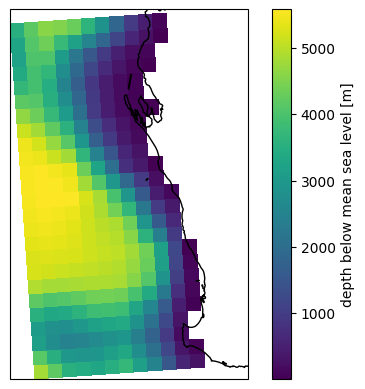

In [43]:
fig, ax = plt.subplots(subplot_kw=dict(projection=ccrs.PlateCarree()))
p = dsgrid.depth.isel(time=0, drop=True).plot(ax=ax, x="longitude", y="latitude")
ax.coastlines()

### Plot gridded Hs

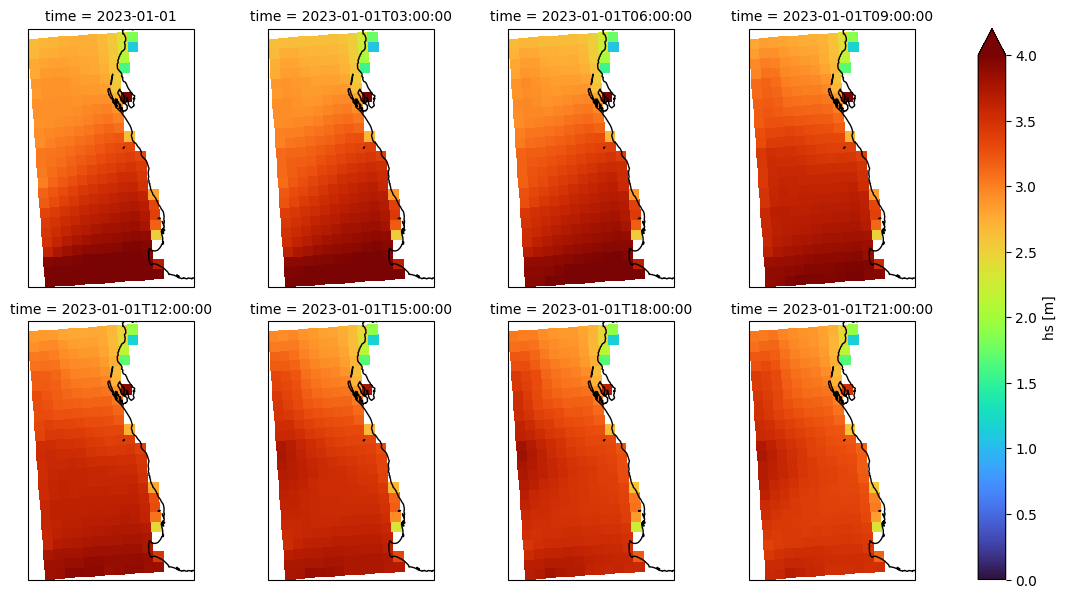

In [44]:
f = dsgrid.hs.isel(time=slice(0, -1, 3)).plot(
    x="longitude",
    y="latitude",
    col="time",
    col_wrap=4,
    vmin=0,
    vmax=4,
    cmap="turbo",
    subplot_kws=dict(projection=ccrs.PlateCarree()),
)
f.map(lambda: plt.gca().coastlines())

### Plot gridded wind

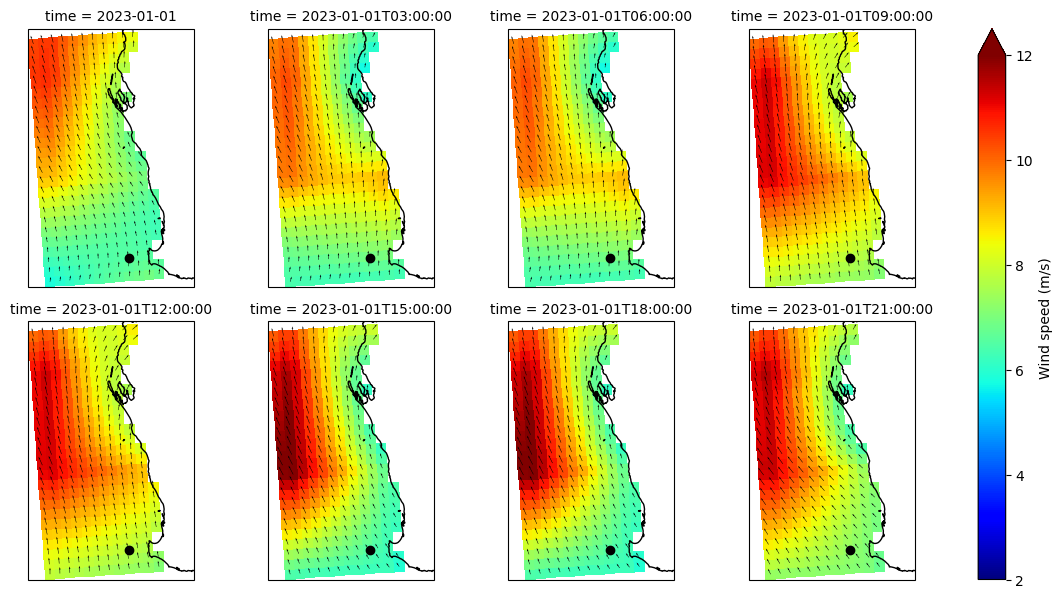

In [45]:
u = dsgrid.xwnd.isel(time=slice(0, -1, 3))
v = dsgrid.ywnd.isel(time=slice(0, -1, 3))
f = np.sqrt(u**2 + v**2).plot(
    x="longitude",
    y="latitude",
    col="time",
    col_wrap=4,
    vmin=2,
    vmax=12,
    cmap="jet",
    cbar_kwargs={"label": "Wind speed (m/s)"},
    subplot_kws=dict(projection=ccrs.PlateCarree()),
)
for ax, time in zip(f.axs.flat, u.time):
    ax.coastlines()
    ax.quiver(u.longitude, u.latitude, u.sel(time=time), v.sel(time=time), scale=200)
    ax.plot(dspec.isel(site=0).lon, dspec.isel(site=0).lat, "ok")

### Plot spectra

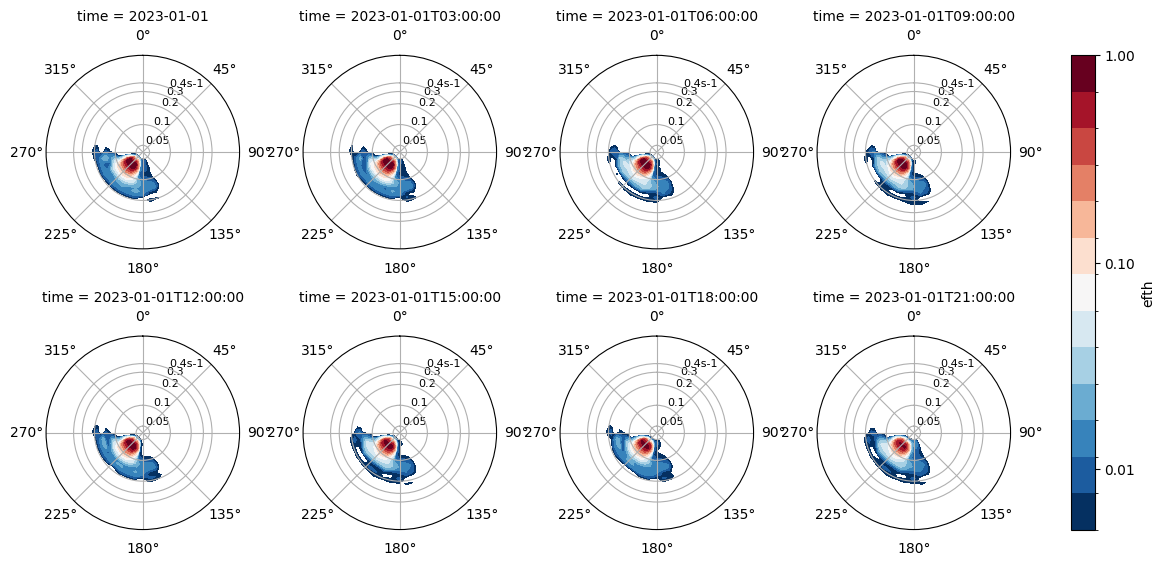

In [46]:
p = dspec.isel(site=0, time=slice(0, -1, 3)).spec.plot(col="time", col_wrap=4)

### Plot timeseries

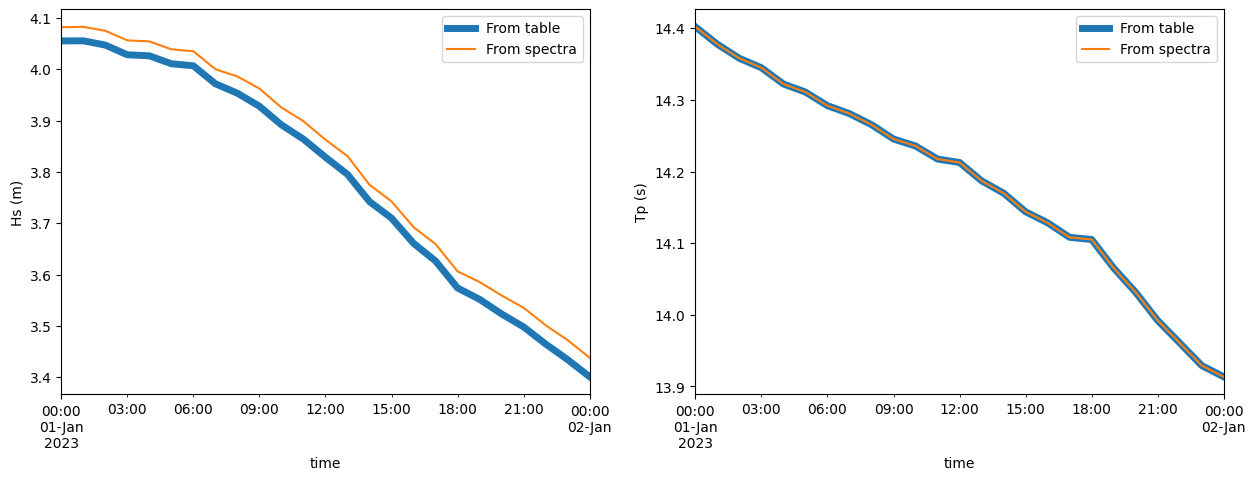

In [47]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

df.Hsig.plot(ax=ax1, label="From table", linewidth=5)
dspec.isel(site=0).spec.hs().to_pandas().plot(ax=ax1, label="From spectra")
ax1.set_ylabel("Hs (m)")
l = ax1.legend()

df.TPsmoo.plot(ax=ax2, label="From table", linewidth=5)
dspec.isel(site=0).spec.tp(smooth=True).to_pandas().plot(ax=ax2, label="From spectra")
ax2.set_ylabel("Tp (s)")
l = ax2.legend()

### Plot hotfile

In [48]:
hotfiles = sorted(
    modeldir.glob(f"{model_run.config.lockup.compute.hotfile.fname.stem}*")
)
hotfiles

[PosixPath('example_procedural/run1/hotfile_20230101T010000.swn'),
 PosixPath('example_procedural/run1/hotfile_20230102T000000.swn')]

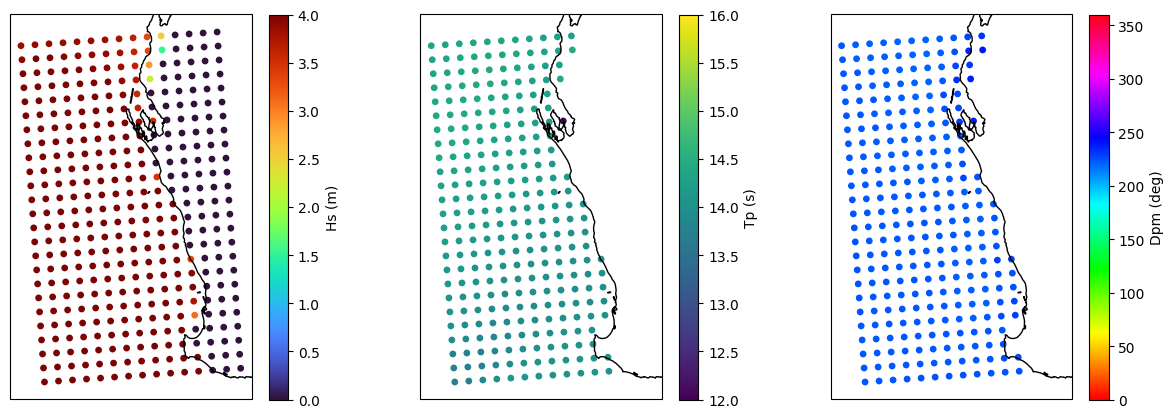

In [49]:
# Investigate why the option to read as grid doesn't work

dset = read_swan(str(hotfiles[-1]), as_site=False)
stats = dset.spec.stats(["hs", "tp", "dpm"]).chunk()

fig, [ax1, ax2, ax3] = plt.subplots(
    1, 3, figsize=(15, 5), subplot_kw=dict(projection=ccrs.PlateCarree())
)
p = ax1.scatter(dset.lon, dset.lat, s=15, c=stats.hs, vmin=0, vmax=4, cmap="turbo")
plt.colorbar(p, label="Hs (m)")
p = ax2.scatter(dset.lon, dset.lat, s=15, c=stats.tp, vmin=12, vmax=16, cmap="viridis")
plt.colorbar(p, label="Tp (s)")
p = ax3.scatter(dset.lon, dset.lat, s=15, c=stats.dpm, vmin=0, vmax=360, cmap="hsv")
plt.colorbar(p, label="Dpm (deg)")
for ax in [ax1, ax2, ax3]:
    ax.coastlines()